# AI Card Classifier
find the dataset at: https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import random

# Para mejorar la visualización en notebooks
%matplotlib inline

In [34]:
DATA_DIR = 'dataset'

file_paths = []
original_labels = []
datasets = []

for root, dirs, files in os.walk(DATA_DIR):
    if not files:
        continue
    
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')): # asserts
            file_path = os.path.join(root, file)
            file_paths.append(file_path)
            
            # El nombre de la etiqueta es el nombre de la carpeta
            label = os.path.basename(root)
            original_labels.append(label)
            
            # El nombre del dataset (train/test/valid) es el padre de la carpeta de la etiqueta
            dataset_type = os.path.basename(os.path.dirname(root))
            datasets.append(dataset_type)

# Creamos el DataFrame
df = pd.DataFrame({
    'filepath': file_paths,
    'dataset': datasets,
    'label_original': original_labels
})

print(f"Total de imágenes encontradas: {len(df)}")
df.head()

Total de imágenes encontradas: 8154


,filepath,dataset,label_original
0,dataset\test\ace of clubs\1.jpg,test,ace of clubs
1,dataset\test\ace of clubs\2.jpg,test,ace of clubs
2,dataset\test\ace of clubs\3.jpg,test,ace of clubs
3,dataset\test\ace of clubs\4.jpg,test,ace of clubs
4,dataset\test\ace of clubs\5.jpg,test,ace of clubs


In [35]:
def get_suit_class(label):
    label = label.lower()
    
    if 'hearts' in label or 'heart' in label:
        return 'corazones'
    elif 'diamonds' in label or 'diamond' in label:
        return 'diamantes'
    elif 'spades' in label or 'spade' in label:
        return 'picas'
    elif 'clubs' in label or 'club' in label:
        return 'treboles'
    else:
        return 'outlier'

df['palo'] = df['label_original'].apply(get_suit_class)

print("DataFrame con la nueva clase 'palo':")
df.head()

DataFrame con la nueva clase 'palo':


,filepath,dataset,label_original,palo
0,dataset\test\ace of clubs\1.jpg,test,ace of clubs,treboles
1,dataset\test\ace of clubs\2.jpg,test,ace of clubs,treboles
2,dataset\test\ace of clubs\3.jpg,test,ace of clubs,treboles
3,dataset\test\ace of clubs\4.jpg,test,ace of clubs,treboles
4,dataset\test\ace of clubs\5.jpg,test,ace of clubs,treboles


Distribución de imágenes por palo (Total):
palo
picas        2161
corazones    1975
diamantes    1957
treboles     1936
outlier       125
Name: count, dtype: int64

Distribución de imágenes por palo (Solo Entrenamiento):
palo
picas        2031
corazones    1845
diamantes    1827
treboles     1806
outlier       115
Name: count, dtype: int64


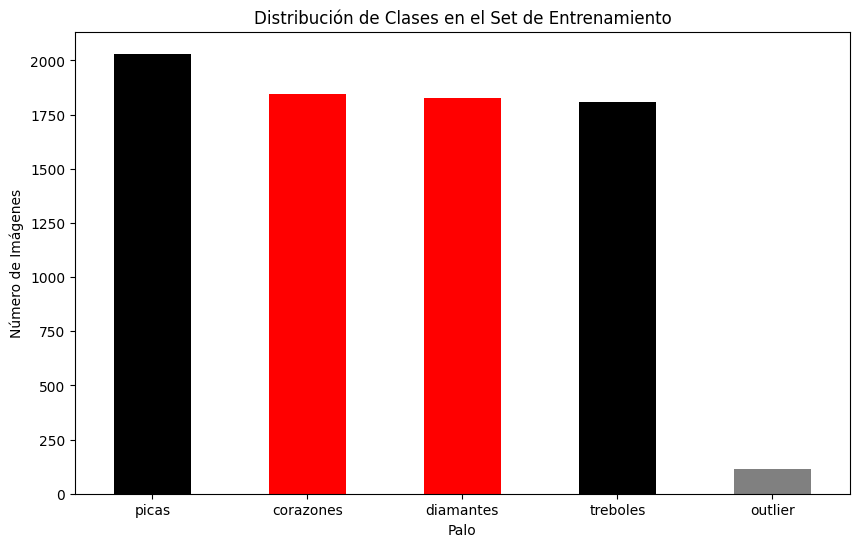

In [36]:
# Estado de equilibrio del dataset
# Imágenes por palo
print("Distribución de imágenes por palo (Total):")
print(df['palo'].value_counts())

print("\nDistribución de imágenes por palo (Solo Entrenamiento):")
print(df[df['dataset'] == 'train']['palo'].value_counts())

plt.figure(figsize=(10, 6))
df[df['dataset'] == 'train']['palo'].value_counts().plot(kind='bar', color=['black', 'red', 'red', 'black', 'grey'])
plt.title('Distribución de Clases en el Set de Entrenamiento')
plt.xlabel('Palo')
plt.ylabel('Número de Imágenes')
plt.xticks(rotation=0)
plt.show()

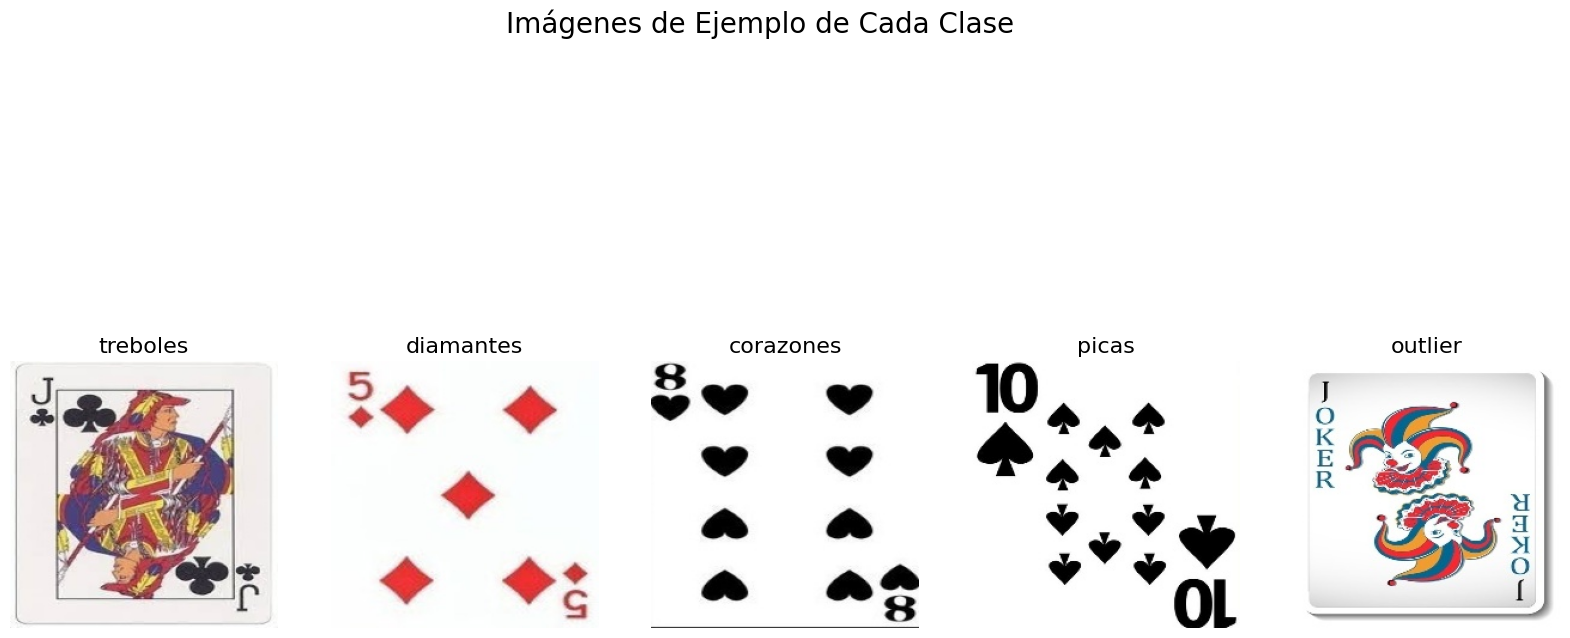

In [37]:
clases = df['palo'].unique()

plt.figure(figsize=(20, 10))
plt.suptitle('Imágenes de Ejemplo de Cada Clase', fontsize=20)

for i, clase in enumerate(clases):
    # 1. Filtramos el DataFrame por la clase actual y el set de 'train'
    df_clase = df[(df['palo'] == clase) & (df['dataset'] == 'train')]
    
    # 2. Rruta de archivo aleatoria
    random_path = random.choice(df_clase['filepath'].values)
    
    # 3. Cargamos la imagen
    # Usamos cv2.imread y lo convertimos de BGR (OpenCV) a RGB (Matplotlib)
    img = cv2.imread(random_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 4. La mostramos
    ax = plt.subplot(1, len(clases), i + 1)
    ax.imshow(img)
    ax.set_title(clase, fontsize=16)
    ax.axis('off')

plt.show()

In [38]:
# Parámetros Clave
IMG_SIZE = 128    # Redimensionar imágenes a 128x128
BATCH_SIZE = 32
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# Dividir el DataFrame
df_train = df[df['dataset'] == 'train'].copy()
df_valid = df[df['dataset'] == 'valid'].copy()
df_test = df[df['dataset'] == 'test'].copy()

print(f"Imágenes de Entrenamiento: {len(df_train)}")
print(f"Imágenes de Validación:   {len(df_valid)}")
print(f"Imágenes de Prueba:       {len(df_test)}")

Imágenes de Entrenamiento: 7624
Imágenes de Validación:   265
Imágenes de Prueba:       265


In [39]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Creamos la "receta" de aumento para los datos de ENTRENAMIENTO
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalizar: Píxeles de [0, 255] a [0, 1]
    rotation_range=20,         # Rota la imagen aleatoriamente hasta 20 grados
    width_shift_range=0.1,     # Mueve la imagen horizontalmente (10%)
    height_shift_range=0.1,    # Mueve la imagen verticalmente (10%)
    shear_range=0.1,           # "Inclina" la imagen
    zoom_range=0.1,            # Hace zoom aleatorio
    horizontal_flip=True,      # Invierte la imagen horizontalmente
    fill_mode='nearest'        # Rellena píxeles nuevos
)

# Normalizamos test y val
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [40]:
# Aumentar muestra de outliers (jokers)

print(f"Tamaño original de df_train: {len(df_train)}")
print(f"Outliers originales en df_train: {len(df_train[df_train['palo'] == 'outlier'])}")

df_outliers = df_train[df_train['palo'] == 'outlier']

# Aumentar outliers
oversample_factor = 20
df_outliers_oversampled = pd.concat([df_outliers] * oversample_factor, ignore_index=True)

# Nuevo df_train
df_train_balanced = pd.concat([
    df_train[df_train['palo'] != 'outlier'],
    df_outliers_oversampled
])

df_train = df_train_balanced.sample(frac=1).reset_index(drop=True)

print(f"\nNuevo tamaño de df_train (balanceado): {len(df_train)}")
print(f"Nuevos 'outliers' en df_train (con copias): {len(df_train[df_train['palo'] == 'outlier'])}")
print("\nNueva distribución de entrenamiento:")
print(df_train['palo'].value_counts())

Tamaño original de df_train: 7624
Outliers originales en df_train: 115

Nuevo tamaño de df_train (balanceado): 9809
Nuevos 'outliers' en df_train (con copias): 2300

Nueva distribución de entrenamiento:
palo
outlier      2300
picas        2031
corazones    1845
diamantes    1827
treboles     1806
Name: count, dtype: int64


In [41]:
print("Creando generador de entrenamiento...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='filepath',
    y_col='palo',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\nCreando generador de validación...")
validation_generator = test_datagen.flow_from_dataframe(
    dataframe=df_valid,
    x_col='filepath',
    y_col='palo',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nCreando generador de prueba...")
test_generator = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='filepath',
    y_col='palo',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Creando generador de entrenamiento...
Found 9809 validated image filenames belonging to 5 classes.

Creando generador de validación...
Found 265 validated image filenames belonging to 5 classes.

Creando generador de prueba...
Found 265 validated image filenames belonging to 5 classes.


In [42]:
from sklearn.utils import class_weight

# Celda para castigo adicional si se equivoca en "jokers"

class_labels = list(train_generator.class_indices.keys())
print(f"Etiquetas numéricas: {train_generator.class_indices}")

class_counts = np.bincount(train_generator.classes)

# Calculamos los pesos
# 'balanced' automáticamente le da más peso a las clases raras
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

# Lo convertimos a un diccionario para Keras
class_weights_dict = dict(enumerate(class_weights))

print("\nSe aplicarán estos pesos durante el entrenamiento:")
for i, label in enumerate(class_labels):
    print(f"  {label} (clase {i}): {class_weights_dict[i]:.2f}")

Etiquetas numéricas: {'corazones': 0, 'diamantes': 1, 'outlier': 2, 'picas': 3, 'treboles': 4}

Se aplicarán estos pesos durante el entrenamiento:
  corazones (clase 0): 1.06
  diamantes (clase 1): 1.07
  outlier (clase 2): 0.85
  picas (clase 3): 0.97
  treboles (clase 4): 1.09


### CNN (Google's MobileNetV2 based)

In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2

In [44]:
# Cargar el modelo
base_model = MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,  # ¡No queremos su capa de clasificación final!
    weights='imagenet'  # Usar los pesos aprendidos en ImageNet
)

# Congelar el modelo base
base_model.trainable = False

print("¡PILA TEXTO! Estructura del modelo base:")
#base_model.summary()

¡PILA TEXTO! Estructura del modelo base:


In [45]:
# Modelo para cartas
model = Sequential([
    base_model,
    # Como un Flatten pero mejor
    GlobalAveragePooling2D(),
    # Capa oculta para aprendizaje
    Dense(128, activation='relu'),
    # Por si hubiese overfitting (apaga el 50% de las neuronas aleatoriamente)
    Dropout(0.5),
    # La capa de salida final (5 neuronas = 5 clases)
    # Usamos 'softmax' para obtener probabilidades
    Dense(5, activation='softmax') 
])

In [46]:
model.compile(
    loss='categorical_crossentropy', # Bueno para clasificación de varias clases
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Aqui no hay tanto texto
print("\nModelo Final")
model.summary()


Modelo Final


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Entrenamiento

In [47]:
#Comprobar la GPU
import tensorflow as tf

print(f"Versión de TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Habilitar el crecimiento de memoria (evita que TF reserve toda la VRAM)
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ ¡GPU detectada y configurada! Se usarán: {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("❌ ADVERTENCIA: No se encontró ninguna GPU. El entrenamiento se ejecutará en la CPU.")
    print("   Asegúrate de tener los drivers de NVIDIA y el toolkit de CUDA correctos para tu versión de TensorFlow.")

Versión de TensorFlow: 2.17.0
❌ ADVERTENCIA: No se encontró ninguna GPU. El entrenamiento se ejecutará en la CPU.
   Asegúrate de tener los drivers de NVIDIA y el toolkit de CUDA correctos para tu versión de TensorFlow.


In [48]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Evitar iteraciones que no mejoran el modelo
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    verbose=1,
    mode='max',
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath='best_card_classifier.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

callbacks_list = [early_stopping, model_checkpoint]

In [49]:
EPOCHS = 20

print("Iniciando el entrenamiento...")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weights_dict,
    callbacks=callbacks_list
)

print("\n¡Entrenamiento completado!")

Iniciando el entrenamiento...
Epoch 1/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.5996 - loss: 1.0486
Epoch 1: val_accuracy improved from None to 0.79245, saving model to best_card_classifier.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 105s 335ms/step - accuracy: 0.6791 - loss: 0.8171 - val_accuracy: 0.7925 - val_loss: 0.5891
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.7565 - loss: 0.6101
Epoch 2: val_accuracy did not improve from 0.79245
307/307 ━━━━━━━━━━━━━━━━━━━━ 108s 351ms/step - accuracy: 0.7635 - loss: 0.5907 - val_accuracy: 0.7849 - val_loss: 0.5419
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.7826 - loss: 0.5432
Epoch 3: val_accuracy did not improve from 0.79245
307/307 ━━━━━━━━━━━━━━━━━━━━ 102s 332ms/step - accuracy: 0.7852 - loss: 0.5348 - val_accuracy: 0.7585 - val_loss: 0.6607
Epoch 4/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.7894 - loss: 0.5116
Epoch 4: val_accuracy improved from 0.79245 to 0.80000, s

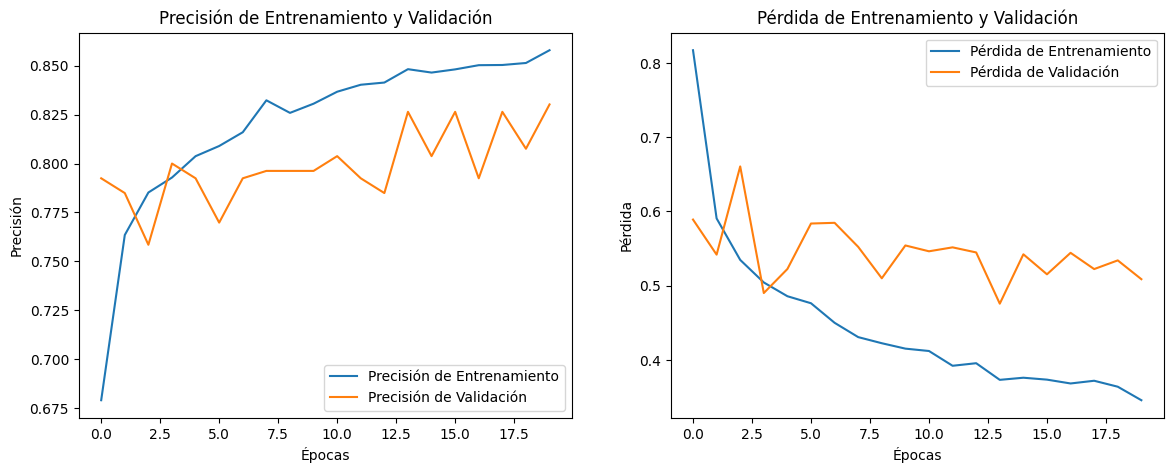

In [50]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Precisión
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión de Entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión de Validación')
plt.legend(loc='lower right')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida de Entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida de Validación')
plt.legend(loc='upper right')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')

plt.show()

In [51]:
# FINE-TUNING

base_model.trainable = True

# Congelar todas las capas EXCEPTO las últimas 20
# (Los modelos de CNN aprenden formas genéricas al principio y específicas al final.
# Solo queremos re-entrenar las capas finales, más específicas.)
print(f"Total de capas en el modelo base: {len(base_model.layers)}")
fine_tune_at = len(base_model.layers) - 20

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Descongelando las últimas {len(base_model.layers) - fine_tune_at} capas del modelo base.")

# TASA DE APRENDIZAJE MUY BAJA A POSTA
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    metrics=['accuracy']
)

print("\n--- Resumen del Modelo (Modo Fine-Tuning) ---")
model.summary()

Total de capas en el modelo base: 154
Descongelando las últimas 20 capas del modelo base.

--- Resumen del Modelo (Modo Fine-Tuning) ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 1,370,693 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [52]:
print("Iniciando Fine-Tuning...")

total_epochs = EPOCHS + 10

history_fine_tune = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1], # Retomar entreno
    validation_data=validation_generator,
    class_weight=class_weights_dict,
    callbacks=callbacks_list
)

print("LISTO")

Iniciando Fine-Tuning...
Epoch 20/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.6920 - loss: 0.9279
Epoch 20: val_accuracy did not improve from 0.83019
307/307 ━━━━━━━━━━━━━━━━━━━━ 81s 250ms/step - accuracy: 0.7276 - loss: 0.7733 - val_accuracy: 0.7887 - val_loss: 0.6380
Epoch 21/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.7743 - loss: 0.6048
Epoch 21: val_accuracy did not improve from 0.83019
307/307 ━━━━━━━━━━━━━━━━━━━━ 120s 390ms/step - accuracy: 0.7831 - loss: 0.5741 - val_accuracy: 0.7698 - val_loss: 0.6402
Epoch 22/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.7944 - loss: 0.5466
Epoch 22: val_accuracy did not improve from 0.83019
307/307 ━━━━━━━━━━━━━━━━━━━━ 139s 379ms/step - accuracy: 0.7966 - loss: 0.5349 - val_accuracy: 0.7962 - val_loss: 0.5731
Epoch 23/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.8098 - loss: 0.4991
Epoch 23: val_accuracy did not improve from 0.83019
307/307 ━━━━━━━━━━━━━━━━━━━━ 118s 385ms/step - ac

### Test

In [56]:
from tensorflow.keras.models import load_model

# Cargar el mejor modelo guardado
print("Cargando el mejor modelo guardado...")
best_model = load_model('best_card_classifier.keras')

# Evaluar el modelo
print("\nEvaluando el modelo con el conjunto de prueba (Test Set)...")
test_loss, test_accuracy = best_model.evaluate(
    test_generator,
    verbose=1
)

print(f"\nResultado de la Prueba:")
print(f"  Pérdida (Loss):     {test_loss:.4f}")
print(f"  Precisión (Accuracy): {test_accuracy*100:.2f}%")

Cargando el mejor modelo guardado...

Evaluando el modelo con el conjunto de prueba (Test Set)...
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7623 - loss: 0.6693

Resultado de la Prueba:
  Pérdida (Loss):     0.6693
  Precisión (Accuracy): 76.23%


In [57]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("Generando predicciones para el conjunto de prueba...")
predictions = best_model.predict(test_generator)

# Probabilidades a una clase
# np.argmax() da el índice de la probabilidad más alta
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Reporte de Clasificación
# Muestra la precisión, recall y F1-score para CADA clase
print("\nReporte de Clasificación:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, predicted_classes)

Generando predicciones para el conjunto de prueba...
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step

Reporte de Clasificación:
              precision    recall  f1-score   support

   corazones       0.96      0.78      0.86        65
   diamantes       0.73      0.94      0.82        65
     outlier       0.00      0.00      0.00         5
       picas       0.64      0.83      0.72        65
    treboles       0.82      0.55      0.66        65

    accuracy                           0.76       265
   macro avg       0.63      0.62      0.61       265
weighted avg       0.77      0.76      0.75       265



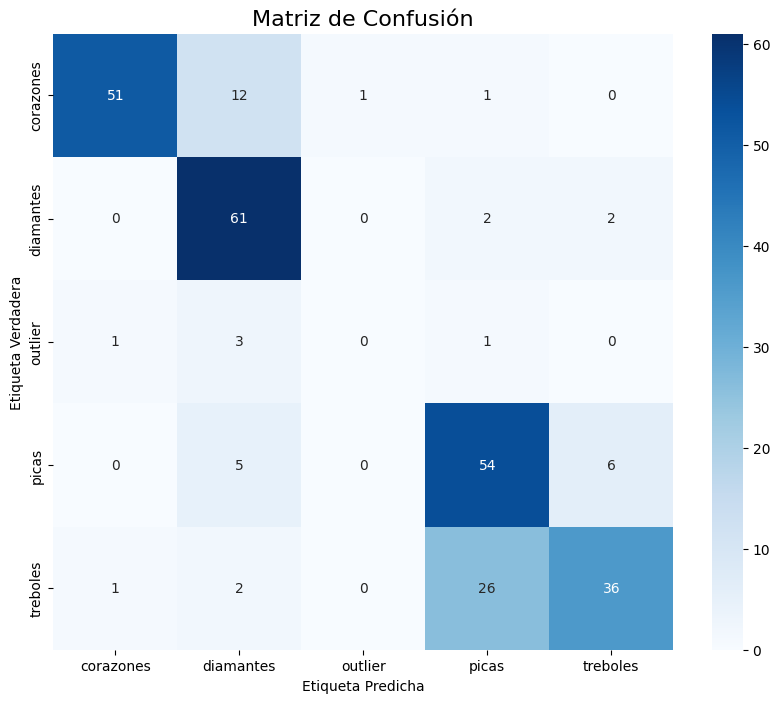

In [58]:
cm_df = pd.DataFrame(cm,
                     index = class_labels, 
                     columns = class_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión', fontsize=16)
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.show()

Mapa de etiquetas: {0: 'corazones', 1: 'diamantes', 2: 'outlier', 3: 'picas', 4: 'treboles'}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


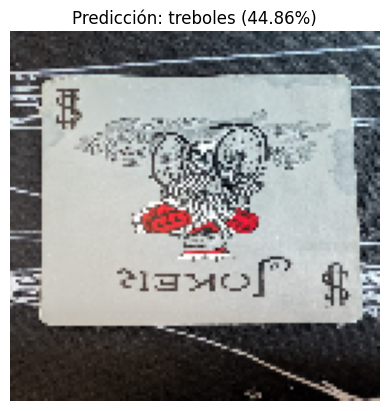

Predicción: treboles
Confianza:  44.86%

Probabilidades completas:
  corazones: 3.44%
  diamantes: 25.94%
  outlier: 16.10%
  picas: 9.66%
  treboles: 44.86%


In [63]:
from tensorflow.keras.preprocessing import image

labels_map = {v: k for k, v in train_generator.class_indices.items()}
print(f"Mapa de etiquetas: {labels_map}")

def predict_card(image_path):
    img = image.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    prediction_probs = best_model.predict(img_batch)
    
    predicted_index = np.argmax(prediction_probs[0])
    predicted_label = labels_map[predicted_index]
    confidence = np.max(prediction_probs[0]) * 100
    
    plt.imshow(img)
    plt.title(f"Predicción: {predicted_label} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()
    
    print(f"Predicción: {predicted_label}")
    print(f"Confianza:  {confidence:.2f}%")
    print("\nProbabilidades completas:")
    for i, label in labels_map.items():
        print(f"  {label}: {prediction_probs[0][i]*100:.2f}%")

predict_card('Joker.jpeg')